<a href="https://colab.research.google.com/github/manuel761/StatsQuest/blob/main/StatsQuest1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
import torch # torch let's us create tensors and also provides helper functions
import torch.nn as nn
import torch.nn.functional as F  #  relu

import matplotlib.pyplot as plt
import seaborn as sns



In [126]:
class myNN(nn.Module):

  def __init__(self):
     # The __init__() method is called when we create an object
     # from this class we intitalize weights and bases

     # When you create a class that inherits from another class
     super().__init__()


     self.w1=torch.tensor(1.43)
     self.b1=torch.tensor(-0.61)

     self.w2=torch.tensor(2.63)
     self.b2=torch.tensor(-0.27)

     self.w3=torch.tensor(-3.89)
     self.w4=torch.tensor(1.35)



  def forward(self,input_values):

    top_x_values=(input_values*self.w1)+self.b1
    bottom_x_values=(input_values*self.w2)+self.b2


    top_y_values=F.relu(top_x_values)
    bottom_y_values=F.relu(bottom_x_values)

    output_values=(top_y_values*self.w3)+(bottom_y_values*self.w4)

    return output_values



In [127]:
model=myNN()


In [128]:
doses=torch.tensor([0.0,0.5,1.0])

model(doses)

tensor([ 0.0000,  1.0023, -0.0038])

In [129]:
torch.round(model(doses), decimals=2)

tensor([0., 1., -0.])

# PLOT X-UP

In [130]:
input_doses = torch.linspace(start=0, end=1, steps=11)


In [131]:
top_x_axis_values=(model.w1*input_doses)+model.b1

top_x_axis_values

tensor([-0.6100, -0.4670, -0.3240, -0.1810, -0.0380,  0.1050,  0.2480,  0.3910,
         0.5340,  0.6770,  0.8200])

In [132]:
top_y_axis_values=F.relu(top_x_axis_values)

top_y_axis_values

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1050, 0.2480, 0.3910, 0.5340,
        0.6770, 0.8200])

Text(0.5, 0, 'Doses')

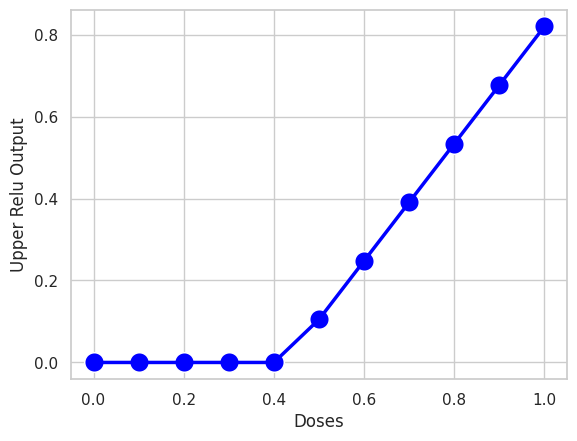

In [133]:

sns.set(style="whitegrid")


sns.scatterplot(x=input_doses,y=top_y_axis_values,color='blue',s=200)

sns.lineplot(x=input_doses,y=top_y_axis_values,color='blue',linewidth=2.5)

plt.ylabel('Upper Relu Output')
plt.xlabel('Doses')

# PLOT X-DOWN

In [134]:
bottom_x_axis_values=(model.w2*input_doses)+model.b2
bottom_x_axis_values

tensor([-0.2700, -0.0070,  0.2560,  0.5190,  0.7820,  1.0450,  1.3080,  1.5710,
         1.8340,  2.0970,  2.3600])

In [135]:
bottom_y_axis_values=F.relu(bottom_x_axis_values)
bottom_y_axis_values

tensor([0.0000, 0.0000, 0.2560, 0.5190, 0.7820, 1.0450, 1.3080, 1.5710, 1.8340,
        2.0970, 2.3600])

Text(0.5, 0, 'Doses')

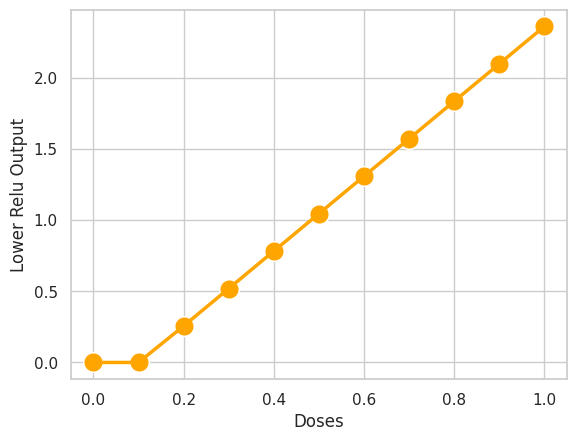

In [136]:
sns.set(style='whitegrid')


sns.scatterplot(x=input_doses,y=bottom_y_axis_values,color='orange',s=200)
sns.lineplot(x=input_doses,y=bottom_y_axis_values,color='orange',linewidth=2.5)
plt.ylabel('Lower Relu Output')
plt.xlabel('Doses')


# BOTH

Text(0.5, 0, 'Dose')

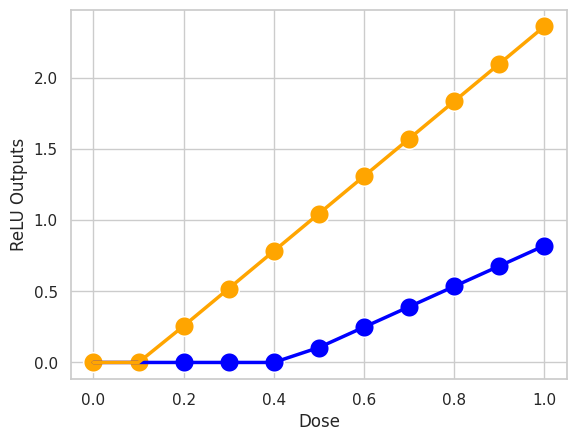

In [137]:

sns.set(style="whitegrid")


sns.scatterplot(x=input_doses,
                y=top_y_axis_values,
                color='blue',
                s=200)


sns.lineplot(x=input_doses,
             y=top_y_axis_values,
             color='blue',
             linewidth=2.5)

sns.scatterplot(x=input_doses,
                y=bottom_y_axis_values,
                color='orange',
                s=200)

sns.lineplot(x=input_doses,
             y=bottom_y_axis_values,
             color='orange',
             linewidth=2.5)


plt.ylabel('ReLU Outputs')
plt.xlabel('Dose')

In [142]:
final_top_y_axis_values=top_y_axis_values*model.w3
final_top_y_axis_values

tensor([-0.0000, -0.0000, -0.0000, -0.0000, -0.0000, -0.4084, -0.9647, -1.5210,
        -2.0773, -2.6335, -3.1898])

In [143]:
final_bottom_y_axis_values=bottom_y_axis_values*model.w4
final_bottom_y_axis_values

tensor([0.0000, 0.0000, 0.3456, 0.7007, 1.0557, 1.4108, 1.7658, 2.1209, 2.4759,
        2.8310, 3.1860])

Text(0.5, 0, 'Dose')

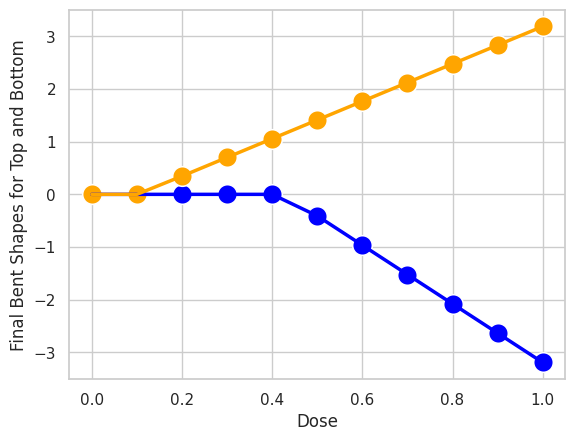

In [144]:
sns.set(style="whitegrid")

sns.scatterplot(x=input_doses,
                y=final_top_y_axis_values,
                color='blue',
                s=200)

## Connect those points with a line (top)
sns.lineplot(x=input_doses,
             y=final_top_y_axis_values,
             color='blue',
             linewidth=2.5)

## Draw the individual points (bottom)
sns.scatterplot(x=input_doses,
                y=final_bottom_y_axis_values,
                color='orange',
                s=200)

## Connect those points with a line (bottom)
sns.lineplot(x=input_doses,
             y=final_bottom_y_axis_values,
             color='orange',
             linewidth=2.5)

## now label the y- and x-axes.
plt.ylabel('Final Bent Shapes for Top and Bottom')
plt.xlabel('Dose')

In [145]:
final_bent_shape=final_top_y_axis_values+final_bottom_y_axis_values
final_bent_shape

tensor([ 0.0000,  0.0000,  0.3456,  0.7007,  1.0557,  1.0023,  0.8011,  0.5999,
         0.3986,  0.1974, -0.0038])

Text(0.5, 0, 'Dose')

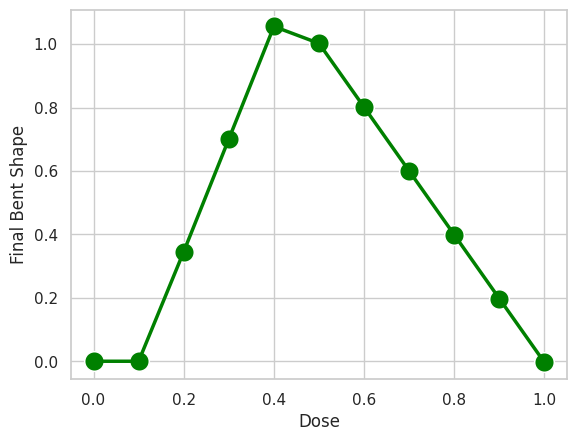

In [146]:
sns.set(style="whitegrid")


sns.scatterplot(x=input_doses,
                y=final_bent_shape,
                color='green',
                s=200)

sns.lineplot(x=input_doses,
             y=final_bent_shape,
             color='green',
             linewidth=2.5)


plt.ylabel('Final Bent Shape')
plt.xlabel('Dose')